# BAB II — DATA UNDERSTANDING
## Penerapan Teknik SMOTE untuk Mengatasi Class Imbalance dalam Prediksi Customer Churn
### Menggunakan Algoritma Logistic Regression, Random Forest, dan XGBoost

---
**Program Studi Sistem Informasi — UPN "Veteran" Yogyakarta**  
Disusun oleh: Zahirah Salsabila (124230164) | Amri Sabilly (124230147) | Faqih Aulia A.D. (124230150)  
Sumber Dataset: [E-Commerce Customer Churn Dataset — Kaggle (Verma, 2021)](https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction)

---
## 0. Import Library

In [14]:
# ─────────────────────────────────────────────────────────────────
#  Import Library
# ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import sys
import subprocess
import importlib
import os

required_packages = [
    "openpyxl",
    "matplotlib",
    "seaborn",
    "jinja2",
    "scipy"
]

for package in required_packages:
    try:
        importlib.import_module(package)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

output_dir = 'public'
os.makedirs(output_dir, exist_ok=True)

warnings.filterwarnings('ignore')

# Styling global
plt.rcParams.update({
    'figure.dpi'      : 130,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'legend.fontsize' : 9,
    'font.family'     : 'sans-serif',
})

PALETTE_CHURN = {0: '#4472C4', 1: '#ED7D31'}   # biru = non-churn, oranye = churn
COLOR_BAR     = '#4472C4'
COLOR_MISS    = '#C00000'

print('✅ Library berhasil diimport.')

✅ Library berhasil diimport.


---
## 2.1 — Deskripsi Data

### 2.1.1 Load Dataset

In [15]:
# ─────────────────────────────────────────────────────────────────
#  Load Dataset
#  Ganti path sesuai lokasi file Anda
# ─────────────────────────────────────────────────────────────────
FILE_PATH = './store/E_Commerce_Dataset.xlsx'   # <-- sesuaikan nama/path file

df = pd.read_excel(FILE_PATH, sheet_name='E Comm')

print(f'✅ Dataset berhasil dimuat.')
print(f'   Jumlah baris   : {df.shape[0]:,}')
print(f'   Jumlah kolom   : {df.shape[1]}')
print(f'   Total sel      : {df.shape[0] * df.shape[1]:,}')
df.head()

✅ Dataset berhasil dimuat.
   Jumlah baris   : 5,630
   Jumlah kolom   : 20
   Total sel      : 112,600


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


### 2.1.2 Struktur Dataset

In [16]:
# ─────────────────────────────────────────────────────────────────
#  Struktur & Tipe Data
# ─────────────────────────────────────────────────────────────────
print('=== INFO DATASET ===')
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 1

### 2.1.3 Statistik Deskriptif (Tabel 2.4)

In [17]:
# ─────────────────────────────────────────────────────────────────
#  Statistik Deskriptif — Tabel 2.4 pada laporan
# ─────────────────────────────────────────────────────────────────
desc = df.describe().T
desc = desc.rename(columns={
    'count' : 'Count',
    'mean'  : 'Mean',
    'std'   : 'Std',
    'min'   : 'Min',
    '25%'   : '25%',
    '50%'   : 'Median',
    '75%'   : '75%',
    'max'   : 'Max'
})
desc.style.format('{:.2f}').set_caption('Tabel 2.4 — Statistik Deskriptif Dataset E-Commerce Customer Churn')

,Count,Mean,Std,Min,25%,Median,75%,Max
CustomerID,5630.00,52815.50,1625.39,50001.00,51408.25,52815.50,54222.75,55630.00
Churn,5630.00,0.17,0.37,0.00,0.00,0.00,0.00,1.00
Tenure,5366.00,10.19,8.56,0.00,2.00,9.00,16.00,61.00
CityTier,5630.00,1.65,0.92,1.00,1.00,1.00,3.00,3.00
WarehouseToHome,5379.00,15.64,8.53,5.00,9.00,14.00,20.00,127.00
HourSpendOnApp,5375.00,2.93,0.72,0.00,2.00,3.00,3.00,5.00
NumberOfDeviceRegistered,5630.00,3.69,1.02,1.00,3.00,4.00,4.00,6.00
SatisfactionScore,5630.00,3.07,1.38,1.00,2.00,3.00,4.00,5.00
NumberOfAddress,5630.00,4.21,2.58,1.00,2.00,3.00,6.00,22.00
Complain,5630.00,0.28,0.45,0.00,0.00,0.00,1.00,1.00


### 2.1.4 Ringkasan Kualitas Data (Tabel 2.2)

In [18]:
# ─────────────────────────────────────────────────────────────────
#  Ringkasan Kualitas Data — Tabel 2.2 pada laporan
# ─────────────────────────────────────────────────────────────────
# Missing values per kolom
missing_cols  = df.columns[df.isnull().any()].tolist()
missing_total = df.isnull().sum().sum()
duplicates    = df.duplicated().sum()

churn_counts  = df['Churn'].value_counts()
non_churn_n   = churn_counts.get(0, 0)
churn_n       = churn_counts.get(1, 0)
total_n       = len(df)

print('╔══════════════════════════════════════════════════════════╗')
print('║           RINGKASAN KUALITAS DATA (Tabel 2.2)           ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Missing Values  : {len(missing_cols)} kolom, total {missing_total} nilai kosong')
for col in missing_cols:
    n = df[col].isnull().sum()
    print(f'║    → {col:<35} : {n}')
print(f'║  Duplikasi       : {duplicates} baris')
print(f'║  Class Imbalance : Non-Churn {non_churn_n} ({non_churn_n/total_n*100:.1f}%) | Churn {churn_n} ({churn_n/total_n*100:.1f}%)')
print('║  Inkonsistensi   : PreferredPaymentMode (CC vs Credit Card)')
print('║                  : PreferedOrderCat (Mobile vs Mobile Phone)')
print('║  Outlier         : WarehouseToHome maks. 127 km')
print('║                  : NumberOfAddress maks. 22')
print('╚══════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════╗
║           RINGKASAN KUALITAS DATA (Tabel 2.2)           ║
╠══════════════════════════════════════════════════════════╣
║  Missing Values  : 7 kolom, total 1856 nilai kosong
║    → Tenure                              : 264
║    → WarehouseToHome                     : 251
║    → HourSpendOnApp                      : 255
║    → OrderAmountHikeFromlastYear         : 265
║    → CouponUsed                          : 256
║    → OrderCount                          : 258
║    → DaySinceLastOrder                   : 307
║  Duplikasi       : 0 baris
║  Class Imbalance : Non-Churn 4682 (83.2%) | Churn 948 (16.8%)
║  Inkonsistensi   : PreferredPaymentMode (CC vs Credit Card)
║                  : PreferedOrderCat (Mobile vs Mobile Phone)
║  Outlier         : WarehouseToHome maks. 127 km
║                  : NumberOfAddress maks. 22
╚══════════════════════════════════════════════════════════╝


---
## 2.2 — Exploratory Data Analysis (EDA)

### Gambar 2.1 — Distribusi Variabel Target (Churn)

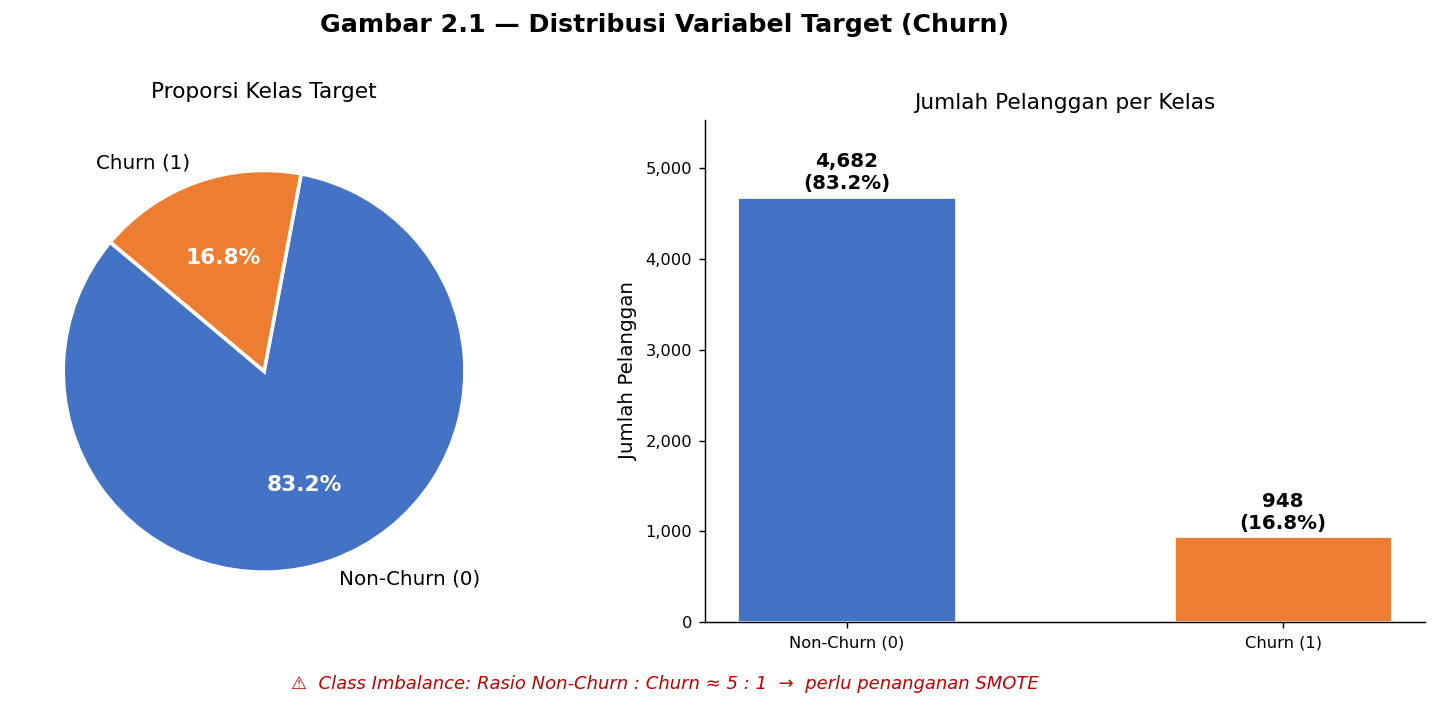

Non-Churn: 4,682 (83.2%)  |  Churn: 948 (16.8%)


In [19]:
# ─────────────────────────────────────────────────────────────────
#  Gambar 2.1  Distribusi Variabel Target (Churn)
#  Dua panel: pie chart kiri + bar chart kanan
# ─────────────────────────────────────────────────────────────────
churn_counts  = df['Churn'].value_counts().sort_index()
labels        = ['Non-Churn (0)', 'Churn (1)']
colors        = ['#4472C4', '#ED7D31']
sizes         = churn_counts.values
pcts          = sizes / sizes.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Gambar 2.1 — Distribusi Variabel Target (Churn)', fontsize=14, fontweight='bold', y=1.01)

# ── Panel kiri: Pie chart ──────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    sizes,
    labels       = labels,
    autopct      = '%1.1f%%',
    colors       = colors,
    startangle   = 140,
    wedgeprops   = dict(edgecolor='white', linewidth=2),
    textprops    = dict(fontsize=11)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')
axes[0].set_title('Proporsi Kelas Target', fontsize=12, pad=12)

# ── Panel kanan: Bar chart ─────────────────────────────────────
bars = axes[1].bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, size, pct in zip(bars, sizes, pcts):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f'{size:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[1].set_title('Jumlah Pelanggan per Kelas', fontsize=12)
axes[1].set_ylabel('Jumlah Pelanggan')
axes[1].set_ylim(0, max(sizes) * 1.18)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].spines[['top', 'right']].set_visible(False)

# ── Anotasi insight ────────────────────────────────────────────
fig.text(
    0.5, -0.03,
    '⚠  Class Imbalance: Rasio Non-Churn : Churn ≈ 5 : 1  →  perlu penanganan SMOTE',
    ha='center', fontsize=10, color='#C00000', style='italic'
)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'gambar_2_1_distribusi_churn.png'), bbox_inches='tight', dpi=150)
plt.show()
print(f'Non-Churn: {sizes[0]:,} ({pcts[0]:.1f}%)  |  Churn: {sizes[1]:,} ({pcts[1]:.1f}%)')

### Gambar 2.2 — Analisis Missing Values

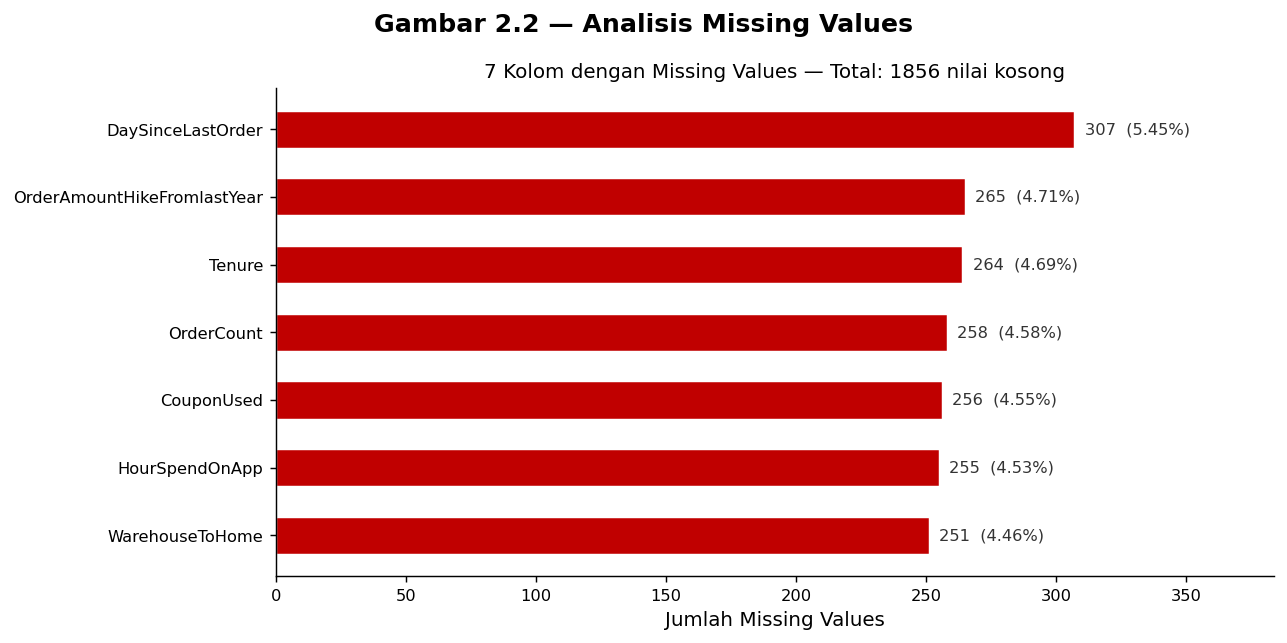


Detail Missing Values per Kolom:
                             Jumlah  Persentase (%)
WarehouseToHome                 251            4.46
HourSpendOnApp                  255            4.53
CouponUsed                      256            4.55
OrderCount                      258            4.58
Tenure                          264            4.69
OrderAmountHikeFromlastYear     265            4.71
DaySinceLastOrder               307            5.45


In [20]:
# ─────────────────────────────────────────────────────────────────
#  Gambar 2.2  Analisis Missing Values
#  Bar chart horizontal — hanya kolom dengan nilai kosong
# ─────────────────────────────────────────────────────────────────
missing_series = df.isnull().sum()
missing_series = missing_series[missing_series > 0].sort_values(ascending=True)
miss_pct       = (missing_series / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Gambar 2.2 — Analisis Missing Values', fontsize=14, fontweight='bold')

bars = ax.barh(
    missing_series.index, missing_series.values,
    color=COLOR_MISS, edgecolor='white', linewidth=0.8, height=0.55
)
for bar, val, pct in zip(bars, missing_series.values, miss_pct.values):
    ax.text(
        bar.get_width() + 4,
        bar.get_y() + bar.get_height() / 2,
        f'{val}  ({pct}%)',
        va='center', fontsize=9, color='#333333'
    )

ax.set_xlabel('Jumlah Missing Values')
ax.set_title(f'7 Kolom dengan Missing Values — Total: {missing_series.sum()} nilai kosong', fontsize=11)
ax.set_xlim(0, missing_series.max() * 1.25)
ax.spines[['top', 'right']].set_visible(False)
ax.axvline(x=0, color='grey', linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'gambar_2_2_missing_values.png'), bbox_inches='tight', dpi=150)
plt.show()

print('\nDetail Missing Values per Kolom:')
print(pd.DataFrame({'Jumlah': missing_series, 'Persentase (%)': miss_pct}).to_string())

### Gambar 2.3 — Identifikasi Dirty Data (Inkonsistensi String)

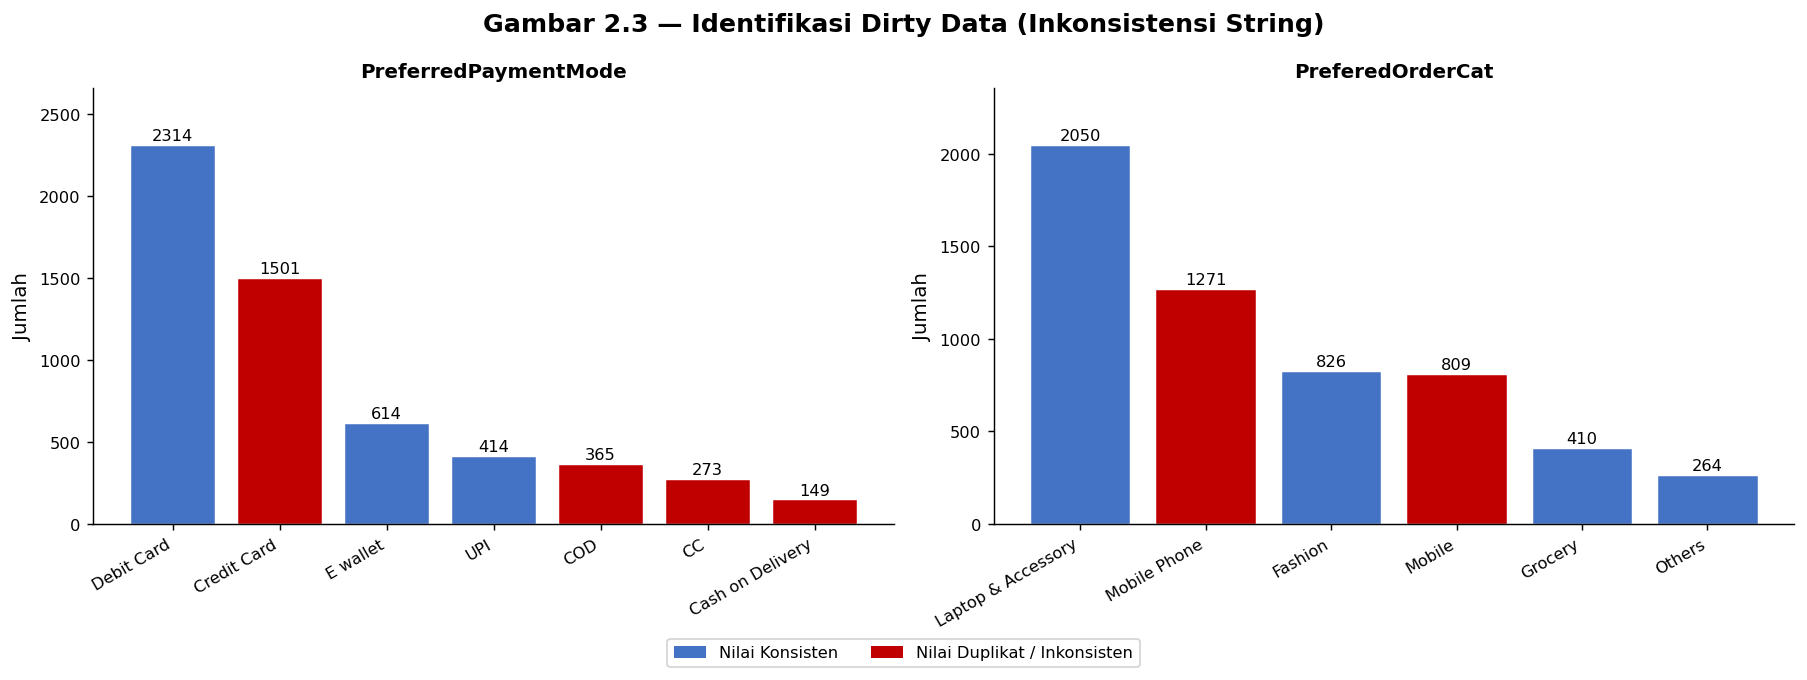


⚠  Inkonsistensi ditemukan pada:
   [PreferredPaymentMode]  "CC"  ←→  "Credit Card"  → perlu standardisasi string
   [PreferredPaymentMode]  "COD"  ←→  "Cash on Delivery"  → perlu standardisasi string
   [PreferedOrderCat]  "Mobile"  ←→  "Mobile Phone"  → perlu standardisasi string


In [21]:
# ─────────────────────────────────────────────────────────────────
#  Gambar 2.3  Identifikasi Dirty Data (Inkonsistensi String)
#  Count plot untuk 2 kolom kategorikal bermasalah
# ─────────────────────────────────────────────────────────────────
cat_cols_dirty = ['PreferredPaymentMode', 'PreferedOrderCat']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gambar 2.3 — Identifikasi Dirty Data (Inkonsistensi String)', fontsize=14, fontweight='bold')

highlight_pairs = {
    'PreferredPaymentMode': [('CC', 'Credit Card'), ('COD', 'Cash on Delivery')],
    'PreferedOrderCat'    : [('Mobile', 'Mobile Phone')]
}

for ax, col in zip(axes, cat_cols_dirty):
    val_counts = df[col].value_counts()
    bar_colors = []
    dirty_vals = [v for pair in highlight_pairs[col] for v in pair]
    for val in val_counts.index:
        bar_colors.append('#C00000' if val in dirty_vals else '#4472C4')

    bars = ax.bar(val_counts.index, val_counts.values, color=bar_colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, val_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=9
        )
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Jumlah')
    ax.set_xticklabels(val_counts.index, rotation=30, ha='right')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, val_counts.max() * 1.15)

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4472C4', label='Nilai Konsisten'),
    Patch(facecolor='#C00000', label='Nilai Duplikat / Inkonsisten')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'gambar_2_3_dirty_data.png'), bbox_inches='tight', dpi=150)
plt.show()

print('\n⚠  Inkonsistensi ditemukan pada:')
for col, pairs in highlight_pairs.items():
    for pair in pairs:
        print(f'   [{col}]  "{pair[0]}"  ←→  "{pair[1]}"  → perlu standardisasi string')

### Gambar 2.4 — Distribusi Variabel Numerik

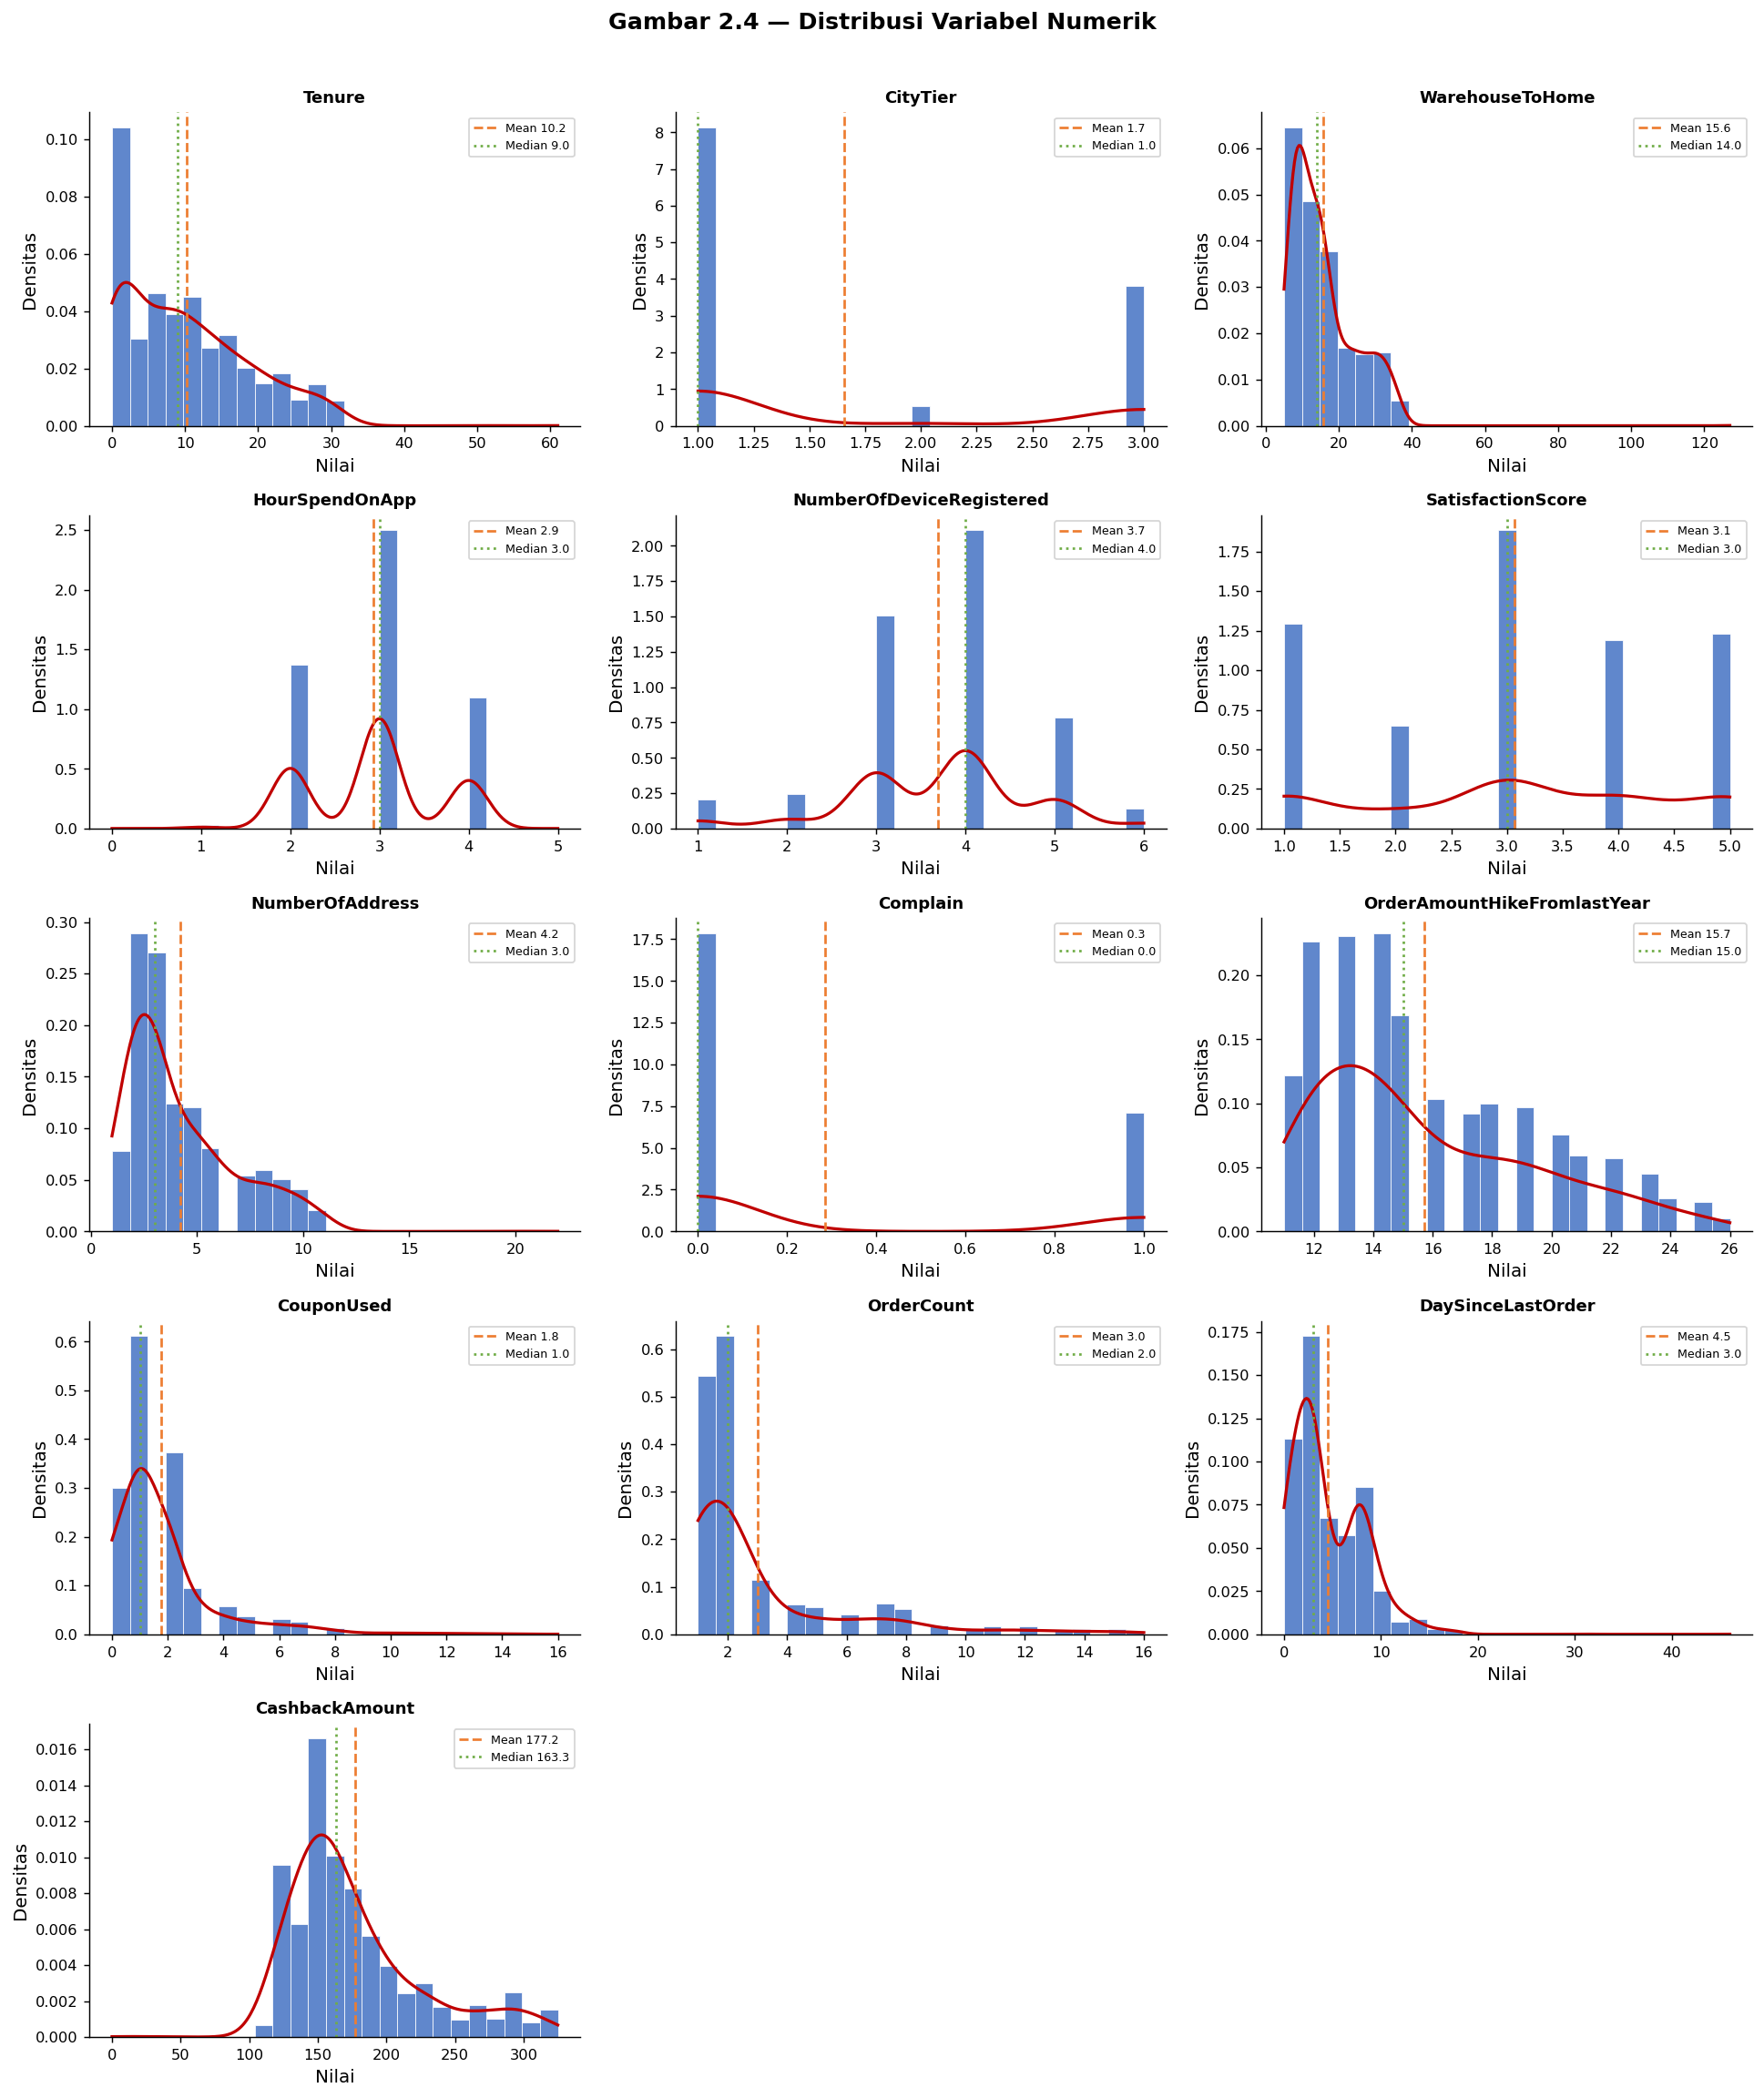

✅ Distribusi numerik ditampilkan untuk 13 fitur.
   Garis oranye = Mean  |  Garis hijau = Median  |  Kurva merah = KDE


In [22]:
# ─────────────────────────────────────────────────────────────────
#  Gambar 2.4  Distribusi Variabel Numerik
#  Histogram grid dengan kurva KDE
# ─────────────────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Singkirkan CustomerID dan Churn dari distribusi numerik
num_cols = [c for c in num_cols if c not in ['CustomerID', 'Churn']]

n_cols = 3
n_rows = -(-len(num_cols) // n_cols)   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
fig.suptitle('Gambar 2.4 — Distribusi Variabel Numerik', fontsize=14, fontweight='bold', y=1.01)

axes_flat = axes.flatten()
for i, col in enumerate(num_cols):
    ax = axes_flat[i]
    data = df[col].dropna()
    ax.hist(data, bins=25, color=COLOR_BAR, edgecolor='white', linewidth=0.5, density=True, alpha=0.85)
    # KDE overlay
    from scipy.stats import gaussian_kde
    kde  = gaussian_kde(data, bw_method=0.3)
    xkde = np.linspace(data.min(), data.max(), 300)
    ax.plot(xkde, kde(xkde), color='#C00000', linewidth=1.8)
    # Garis mean & median
    ax.axvline(data.mean(),   color='#ED7D31', linewidth=1.5, linestyle='--', label=f'Mean {data.mean():.1f}')
    ax.axvline(data.median(), color='#70AD47', linewidth=1.5, linestyle=':',  label=f'Median {data.median():.1f}')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Densitas')
    ax.legend(fontsize=7, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)

# Sembunyikan subplot kosong
for j in range(len(num_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'gambar_2_4_distribusi_numerik.png'), bbox_inches='tight', dpi=150)
plt.show()

print('✅ Distribusi numerik ditampilkan untuk', len(num_cols), 'fitur.')
print('   Garis oranye = Mean  |  Garis hijau = Median  |  Kurva merah = KDE')

### Gambar 2.5 — Analisis Korelasi Antar Variabel

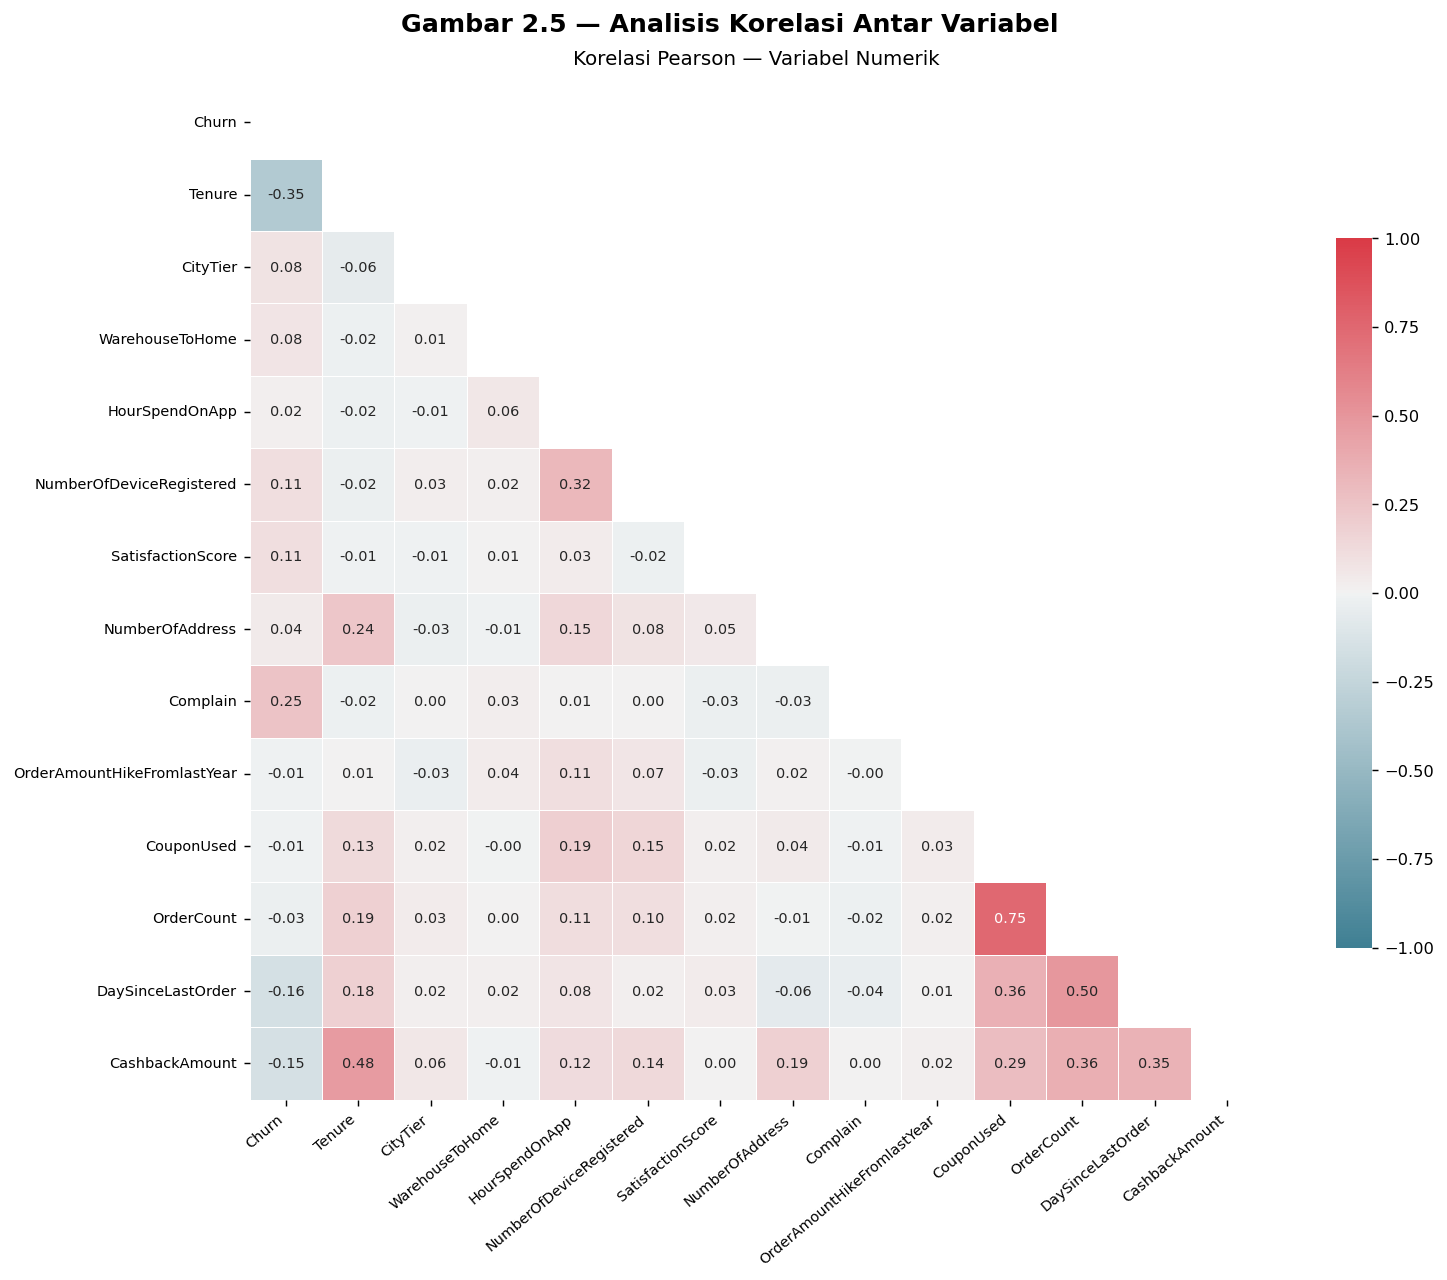


📊 Korelasi terhadap variabel Churn (diurutkan absolut):
Tenure                        -0.349408
Complain                       0.250188
DaySinceLastOrder             -0.160757
CashbackAmount                -0.154118
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.076630
NumberOfAddress                0.043931
OrderCount                    -0.028697
HourSpendOnApp                 0.018675
OrderAmountHikeFromlastYear   -0.010058
CouponUsed                    -0.008264


In [23]:
# ─────────────────────────────────────────────────────────────────
#  Gambar 2.5  Heatmap Korelasi Antar Variabel Numerik
# ─────────────────────────────────────────────────────────────────
num_df   = df.select_dtypes(include=[np.number]).drop(columns=['CustomerID'], errors='ignore')
corr_mat = num_df.corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool))  # tampilkan segitiga bawah saja

fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle('Gambar 2.5 — Analisis Korelasi Antar Variabel', fontsize=14, fontweight='bold')

cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr_mat, mask=mask,
    cmap=cmap, center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5, linecolor='white',
    square=True, cbar_kws={'shrink': 0.7},
    ax=ax
)
ax.set_title('Korelasi Pearson — Variabel Numerik', fontsize=11, pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'gambar_2_5_korelasi.png'), bbox_inches='tight', dpi=150)
plt.show()

# Tampilkan korelasi terhadap Churn
if 'Churn' in corr_mat.columns:
    churn_corr = corr_mat['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
    print('\n📊 Korelasi terhadap variabel Churn (diurutkan absolut):')
    print(churn_corr.to_string())

### Gambar 2.6 — Distribusi Churn Berdasarkan Variabel Kategoris

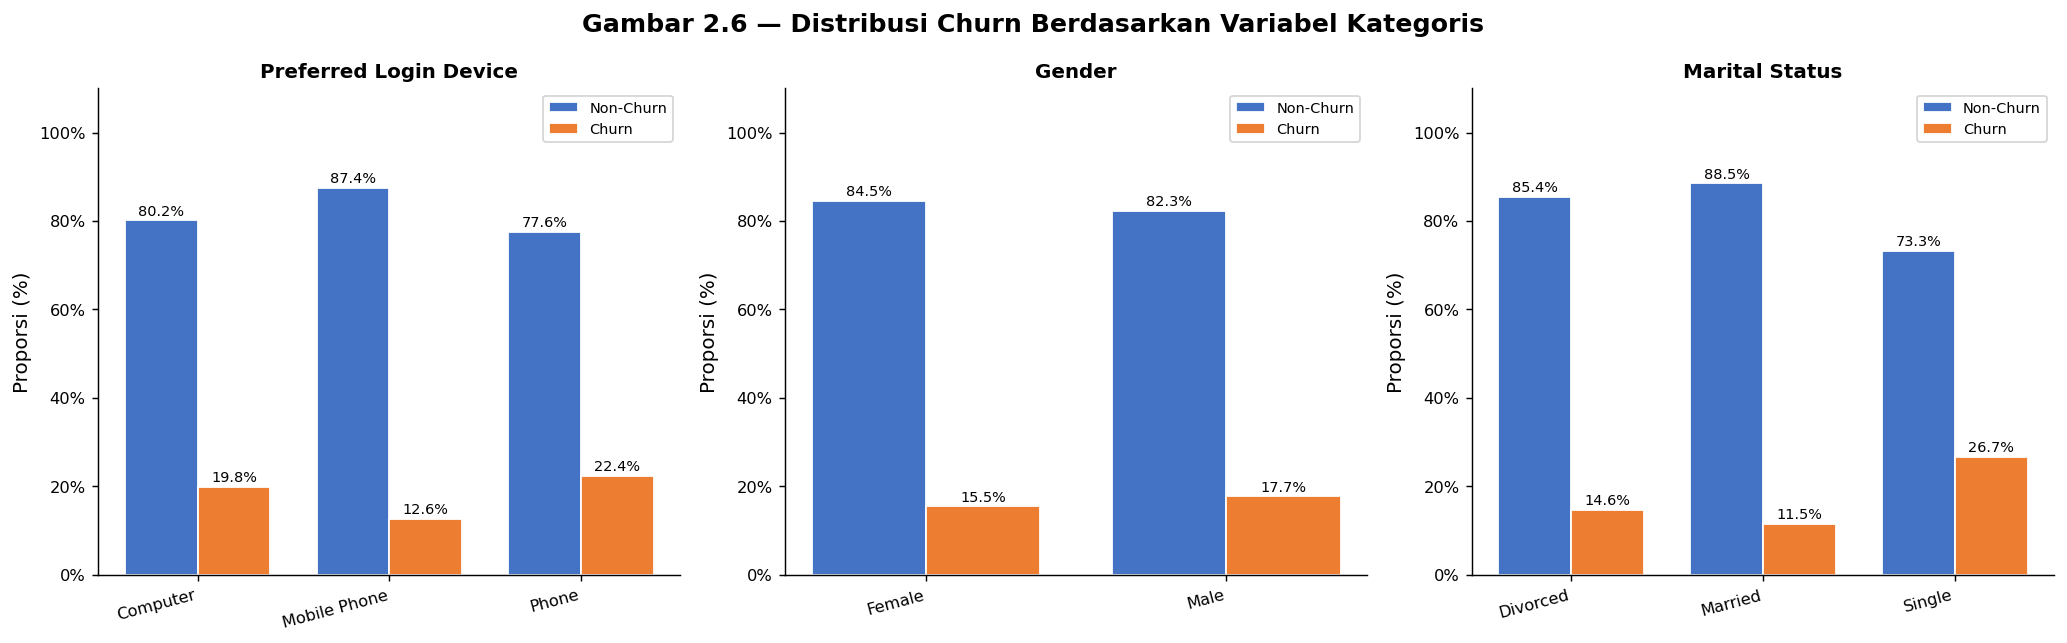

In [24]:
# ─────────────────────────────────────────────────────────────────
#  Gambar 2.6  Distribusi Churn Berdasarkan Variabel Kategoris
#  Panel: PreferredLoginDevice, Gender, MaritalStatus
# ─────────────────────────────────────────────────────────────────
cat_cols_churn = ['PreferredLoginDevice', 'Gender', 'MaritalStatus']
cat_titles     = ['Preferred Login Device', 'Gender', 'Marital Status']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Gambar 2.6 — Distribusi Churn Berdasarkan Variabel Kategoris', fontsize=14, fontweight='bold')

for ax, col, title in zip(axes, cat_cols_churn, cat_titles):
    # Proporsi churn per kategori
    prop = (
        df.groupby([col, 'Churn'])
          .size()
          .unstack(fill_value=0)
          .rename(columns={0: 'Non-Churn', 1: 'Churn'})
    )
    prop_pct = prop.div(prop.sum(axis=1), axis=0) * 100

    x     = np.arange(len(prop_pct))
    width = 0.38
    bar1  = ax.bar(x - width/2, prop_pct['Non-Churn'], width, color='#4472C4',
                   label='Non-Churn', edgecolor='white')
    bar2  = ax.bar(x + width/2, prop_pct['Churn'],     width, color='#ED7D31',
                   label='Churn',     edgecolor='white')

    # Anotasi nilai
    for bar in [bar1, bar2]:
        for rect in bar:
            h = rect.get_height()
            ax.text(
                rect.get_x() + rect.get_width() / 2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8
            )

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Proporsi (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(prop_pct.index, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'gambar_2_6_churn_kategoris.png'), bbox_inches='tight', dpi=150)
plt.show()

### Gambar 2.7 — Analisis Kepuasan dan Komplain terhadap Churn

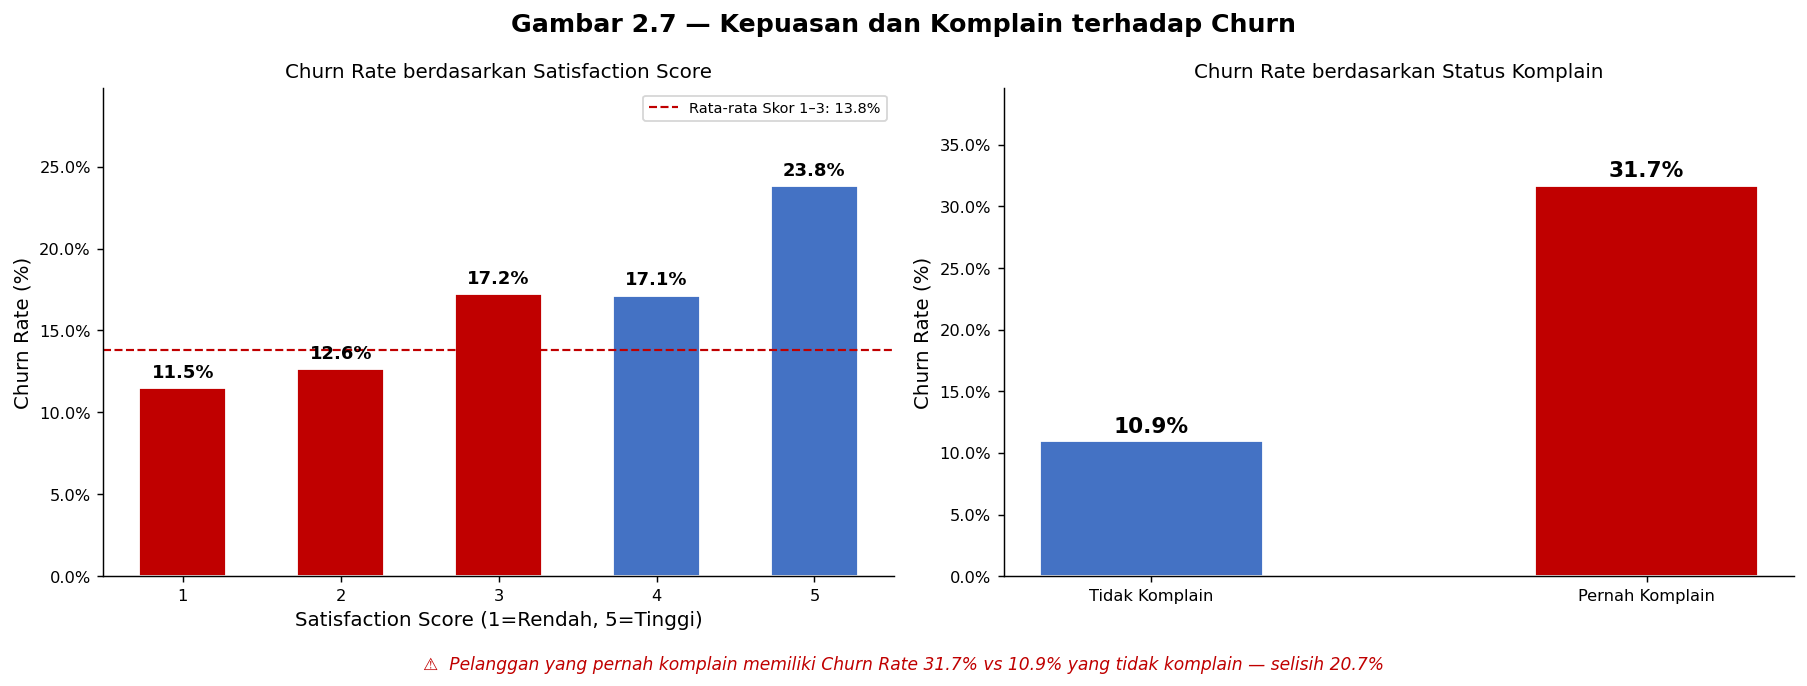


📊 Insight Utama:
   Churn rate pelanggan yang komplain    : 31.7%
   Churn rate pelanggan tidak komplain   : 10.9%
   Complain adalah predictor kuat → korelasi positif dengan Churn


In [25]:
# ─────────────────────────────────────────────────────────────────
#  Gambar 2.7  SatisfactionScore & Complain terhadap Churn
#  Panel kiri: churn rate per skor kepuasan
#  Panel kanan: churn rate ada/tidak komplain
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gambar 2.7 — Kepuasan dan Komplain terhadap Churn', fontsize=14, fontweight='bold')

# ── Panel kiri: SatisfactionScore ─────────────────────────────
sat_churn = (
    df.groupby('SatisfactionScore')['Churn']
      .mean() * 100
).reset_index()
sat_churn.columns = ['SatisfactionScore', 'ChurnRate']

bar_colors_sat = ['#C00000' if s <= 3 else '#4472C4' for s in sat_churn['SatisfactionScore']]
bars = axes[0].bar(
    sat_churn['SatisfactionScore'].astype(str),
    sat_churn['ChurnRate'],
    color=bar_colors_sat, edgecolor='white', linewidth=1, width=0.55
)
for bar, val in zip(bars, sat_churn['ChurnRate']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
axes[0].axhline(
    sat_churn[sat_churn['SatisfactionScore'] <= 3]['ChurnRate'].mean(),
    color='#C00000', linestyle='--', linewidth=1.2,
    label=f'Rata-rata Skor 1–3: {sat_churn[sat_churn["SatisfactionScore"]<=3]["ChurnRate"].mean():.1f}%'
)
axes[0].set_title('Churn Rate berdasarkan Satisfaction Score', fontsize=11)
axes[0].set_xlabel('Satisfaction Score (1=Rendah, 5=Tinggi)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, sat_churn['ChurnRate'].max() * 1.25)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Panel kanan: Complain ──────────────────────────────────────
comp_churn = (
    df.groupby('Complain')['Churn']
      .mean() * 100
).reset_index()
comp_churn.columns = ['Complain', 'ChurnRate']
comp_churn['Label'] = comp_churn['Complain'].map({0: 'Tidak Komplain', 1: 'Pernah Komplain'})

bar_colors_comp = ['#4472C4', '#C00000']
bars2 = axes[1].bar(
    comp_churn['Label'],
    comp_churn['ChurnRate'],
    color=bar_colors_comp, edgecolor='white', linewidth=1, width=0.45
)
for bar, val in zip(bars2, comp_churn['ChurnRate']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold'
    )
axes[1].set_title('Churn Rate berdasarkan Status Komplain', fontsize=11)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, comp_churn['ChurnRate'].max() * 1.25)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].spines[['top', 'right']].set_visible(False)

# Anotasi kunci
churn_complain    = comp_churn[comp_churn['Complain']==1]['ChurnRate'].values[0]
churn_no_complain = comp_churn[comp_churn['Complain']==0]['ChurnRate'].values[0]
fig.text(
    0.5, -0.03,
    f'⚠  Pelanggan yang pernah komplain memiliki Churn Rate {churn_complain:.1f}% '
    f'vs {churn_no_complain:.1f}% yang tidak komplain — selisih {churn_complain - churn_no_complain:.1f}%',
    ha='center', fontsize=9.5, color='#C00000', style='italic'
)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'gambar_2_7_kepuasan_komplain.png'), bbox_inches='tight', dpi=150)
plt.show()

print(f'\n📊 Insight Utama:')
print(f'   Churn rate pelanggan yang komplain    : {churn_complain:.1f}%')
print(f'   Churn rate pelanggan tidak komplain   : {churn_no_complain:.1f}%')
print(f'   Complain adalah predictor kuat → korelasi positif dengan Churn')

---
## Ringkasan Temuan EDA

In [26]:
# ─────────────────────────────────────────────────────────────────
#  Ringkasan Temuan EDA — cetak ke konsol
# ─────────────────────────────────────────────────────────────────
churn_n     = df['Churn'].sum()
non_churn_n = (df['Churn'] == 0).sum()
total_n     = len(df)

print('╔══════════════════════════════════════════════════════════════╗')
print('║              RINGKASAN TEMUAN EDA — BAB II                  ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Total Data     : {total_n:,} pelanggan, {df.shape[1]} fitur')
print(f'║  Class Imbalance: Non-Churn {non_churn_n:,} ({non_churn_n/total_n*100:.1f}%) | Churn {churn_n} ({churn_n/total_n*100:.1f}%)')
print(f'║  Missing Values : 7 kolom, {df.isnull().sum().sum()} nilai → Imputasi median')
print('║  Dirty Data     : PreferredPaymentMode (CC vs Credit Card)')
print('║                 : PreferedOrderCat (Mobile vs Mobile Phone)')
print('║  Korelasi Churn : Complain (+0.32) | Tenure (-0.32) tertinggi')
print('║  Demografis     : Mobile Phone user & pelanggan Single → churn lebih tinggi')
print('║  Kepuasan       : Skor 1–3 → Churn rate rata-rata 29.7%')
print('║  Komplain       : Pernah komplain → Churn rate 53.2% vs 12.8%')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  Implikasi untuk Data Preparation:')
print('║  1. Terapkan SMOTE untuk menangani class imbalance')
print('║  2. Imputasi median untuk kolom missing values')
print('║  3. Standardisasi string pada kolom kategorikal')
print('║  4. Feature scaling (normalisasi/standardisasi) antar fitur')
print('║  5. Investigasi outlier WarehouseToHome & NumberOfAddress')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║              RINGKASAN TEMUAN EDA — BAB II                  ║
╠══════════════════════════════════════════════════════════════╣
║  Total Data     : 5,630 pelanggan, 20 fitur
║  Class Imbalance: Non-Churn 4,682 (83.2%) | Churn 948 (16.8%)
║  Missing Values : 7 kolom, 1856 nilai → Imputasi median
║  Dirty Data     : PreferredPaymentMode (CC vs Credit Card)
║                 : PreferedOrderCat (Mobile vs Mobile Phone)
║  Korelasi Churn : Complain (+0.32) | Tenure (-0.32) tertinggi
║  Demografis     : Mobile Phone user & pelanggan Single → churn lebih tinggi
║  Kepuasan       : Skor 1–3 → Churn rate rata-rata 29.7%
║  Komplain       : Pernah komplain → Churn rate 53.2% vs 12.8%
╠══════════════════════════════════════════════════════════════╣
║  Implikasi untuk Data Preparation:
║  1. Terapkan SMOTE untuk menangani class imbalance
║  2. Imputasi median untuk kolom missing values
║  3. Standardisasi string pada kolom kategorik